In [1]:
# Load packages
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle

from FDApy import DenseFunctionalData, MultivariateFunctionalData
from FDApy.representation import DenseArgvals, DenseValues
from FDApy.preprocessing import MFPCA
from FDApy.visualization import plot, plot_multivariate

from nba import NbaScraper, ShotCharts

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r'\usepackage{amsfonts}'
})

In [2]:
# Load MFPCA results
with open('./data/MFPCA_cv.pickle', 'rb') as f:
    mfpca = pickle.load(f)

In [3]:
pct = 100 * mfpca.eigenvalues / np.sum(mfpca.eigenvalues)

In [4]:
mfpca.eigenfunctions.data[0].norm(squared=True)

array([0.73318091, 0.72988071, 0.84770685, 0.89475124, 0.8268743 ,
       0.78522658, 0.52697385, 0.85402683, 0.8034813 , 0.83188763,
       0.82664797, 0.77632955, 0.67118687, 0.79188619, 0.63977538,
       0.82789565, 0.73169639, 0.66938705, 0.83473493, 0.78731726])

In [5]:
mfpca.eigenfunctions.data[1].norm(squared=True)

array([0.26681909, 0.27011929, 0.15229315, 0.10524876, 0.1731257 ,
       0.21477342, 0.47302615, 0.14597317, 0.1965187 , 0.16811237,
       0.17335203, 0.22367045, 0.32881313, 0.20811381, 0.36022462,
       0.17210435, 0.26830361, 0.33061295, 0.16526507, 0.21268274])

In [6]:
mfpca.eigenfunctions.data[0].norm(squared=True) + mfpca.eigenfunctions.data[1].norm(squared=True)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

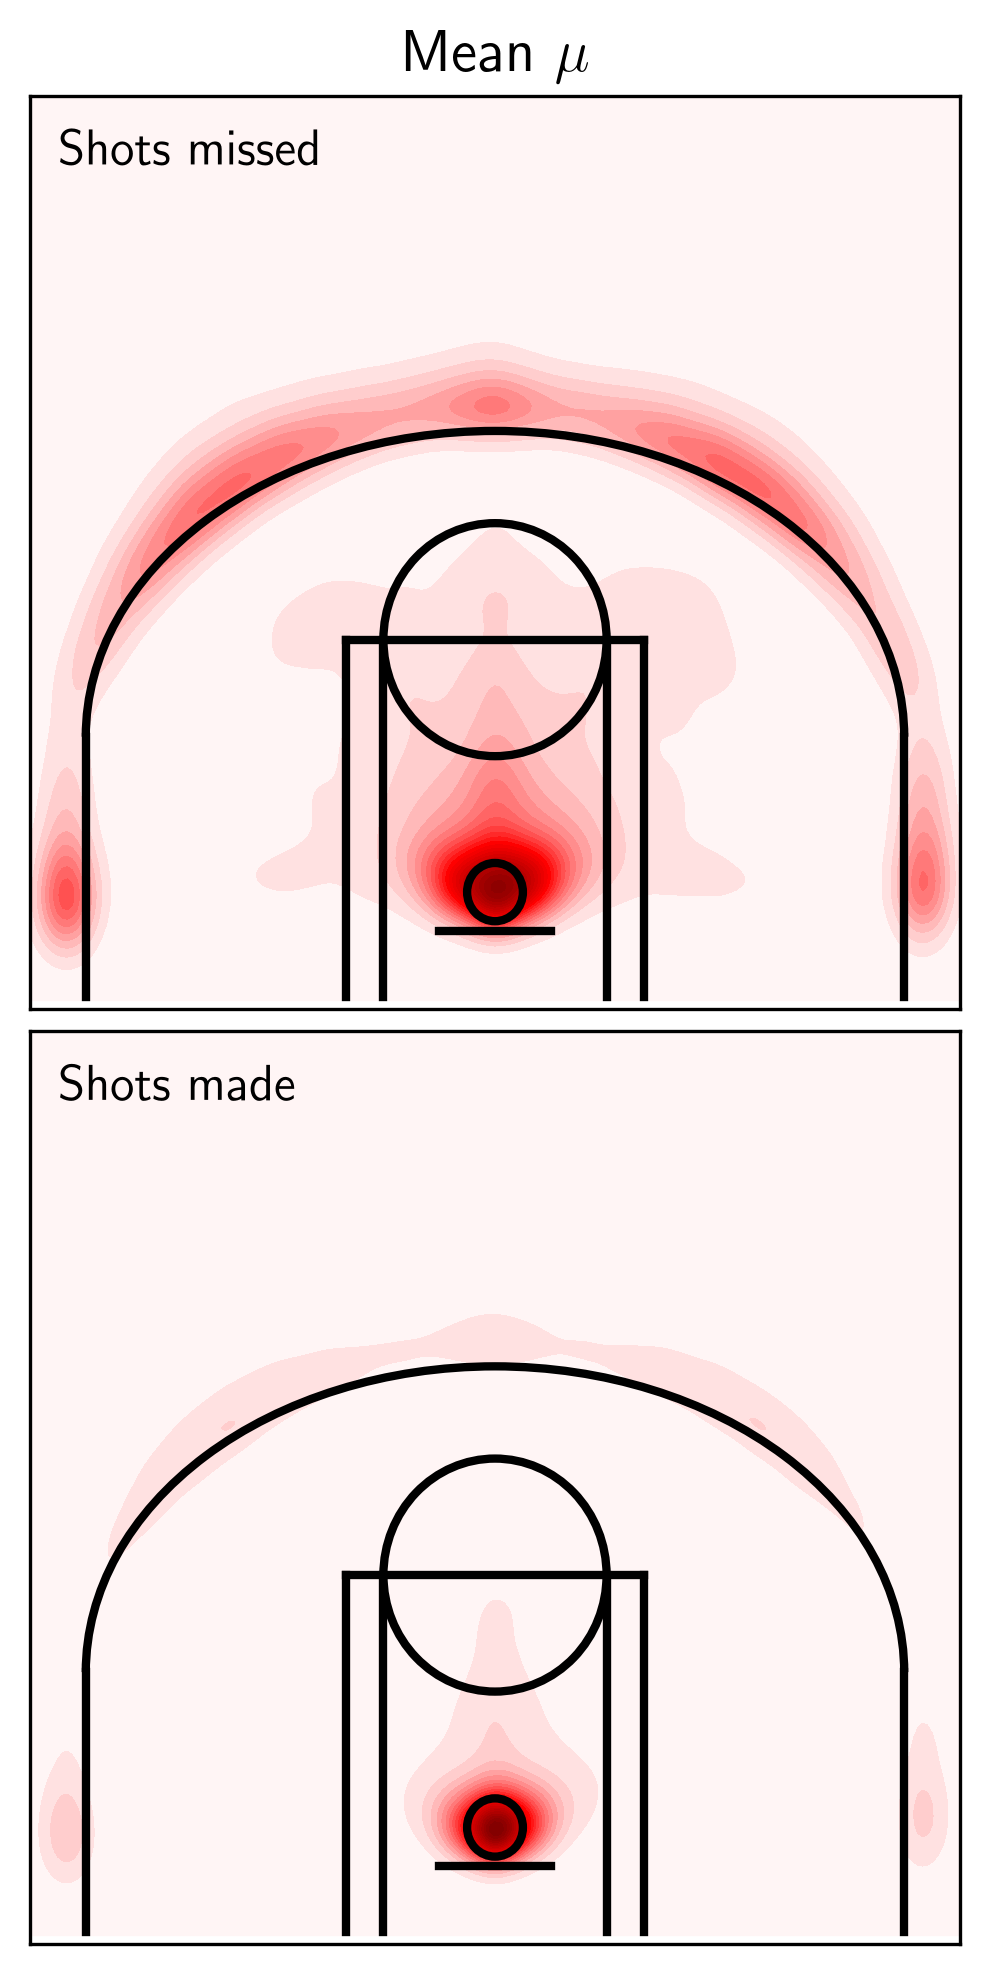

In [7]:
# Mean
fig, ax = plt.subplots(
    2, 1,
    figsize=(4, 8),
    facecolor='white',
    edgecolor='black',
    dpi=300
)
ax[0], ax[1] = ShotCharts.mean_chart_2(
    ax[0], ax[1], mfpca, 'Shots missed', 'Shots made'
)
ax[0].set_title(f"Mean $\\mu$", fontsize='x-large')

plt.subplots_adjust(hspace=0.025)
plt.savefig('./figures/mean_normalized_cv.eps', transparent=True, format='eps')
plt.show()

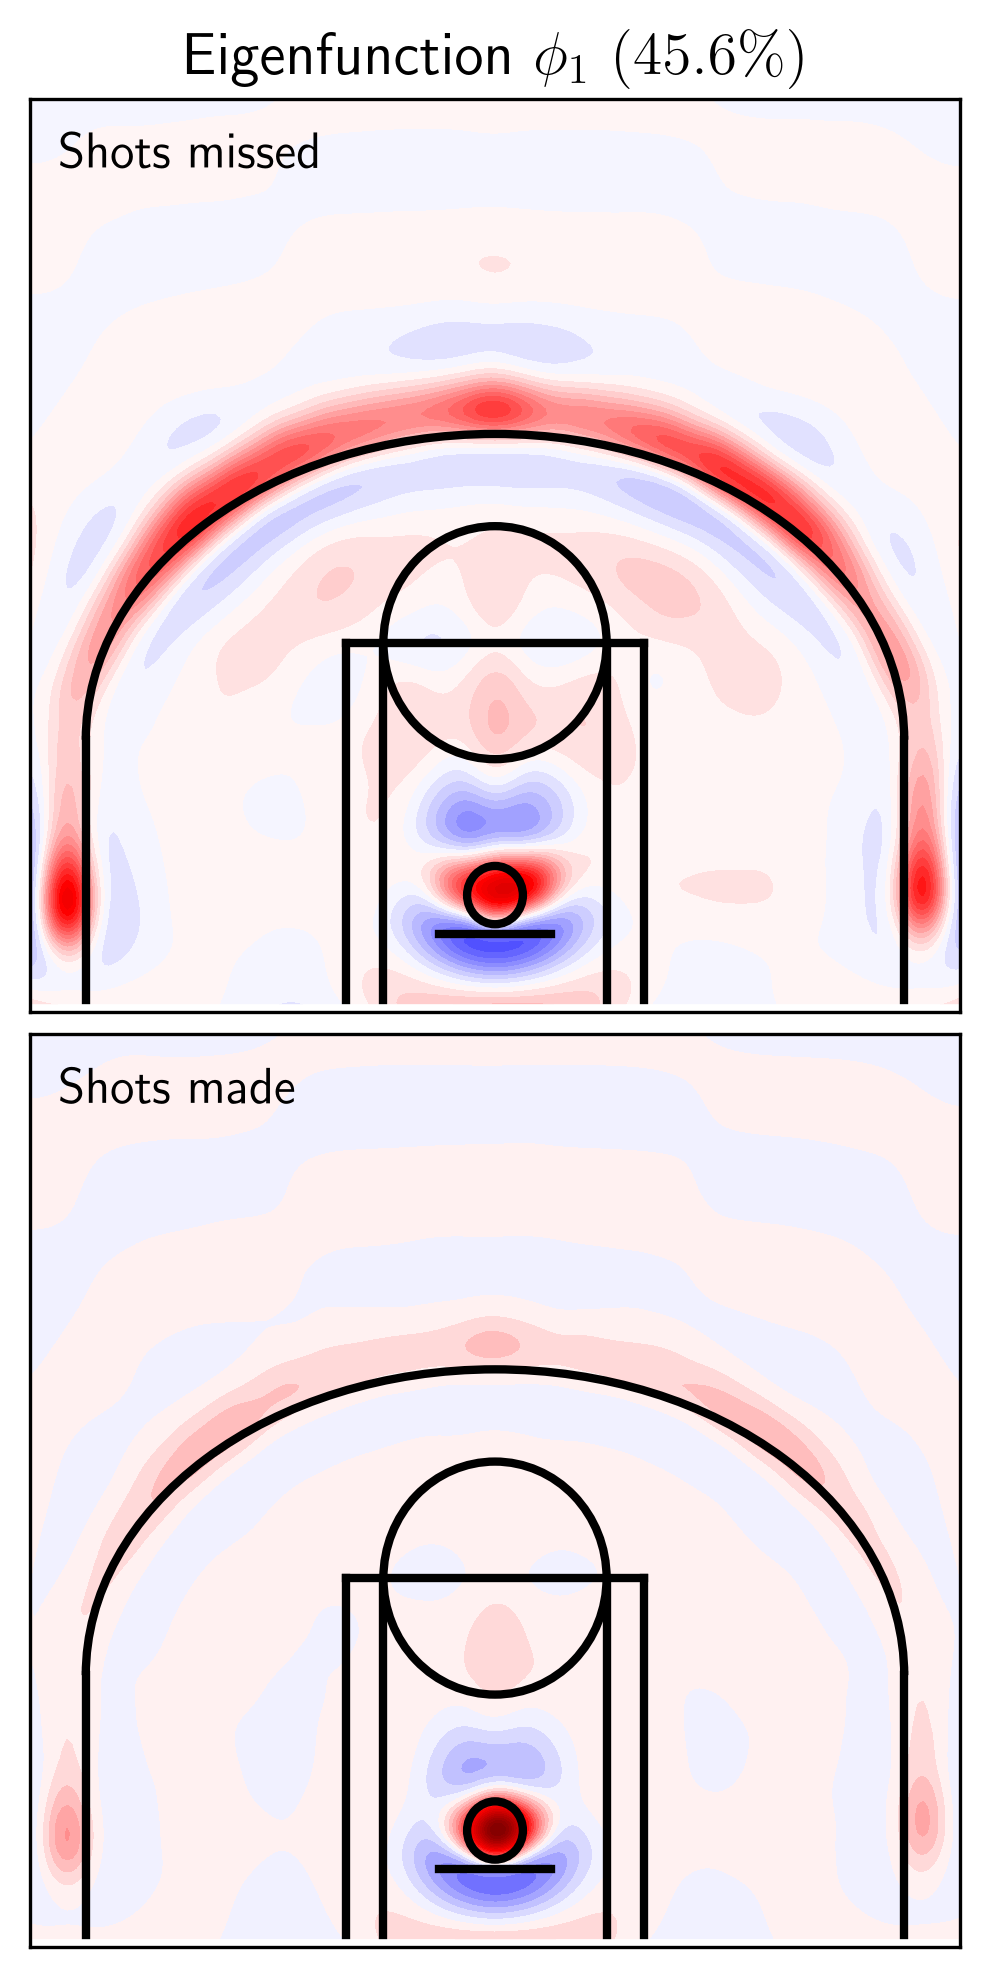

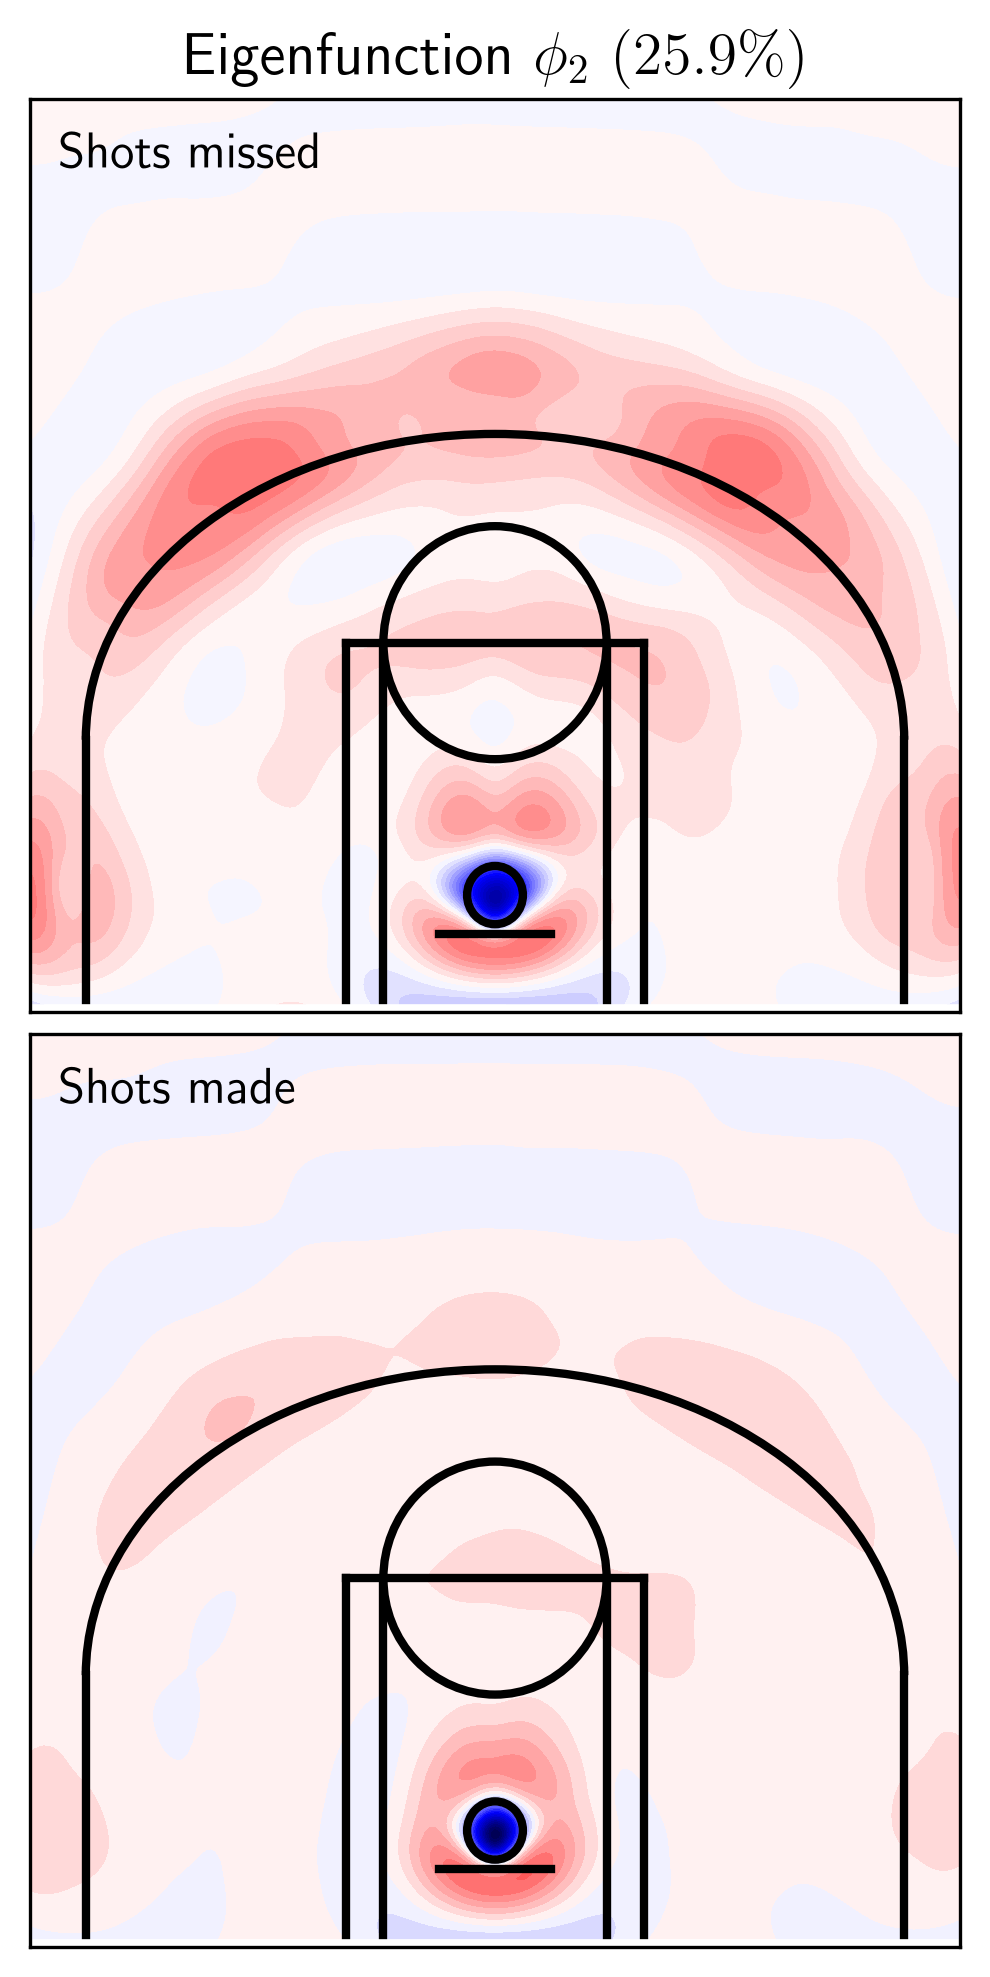

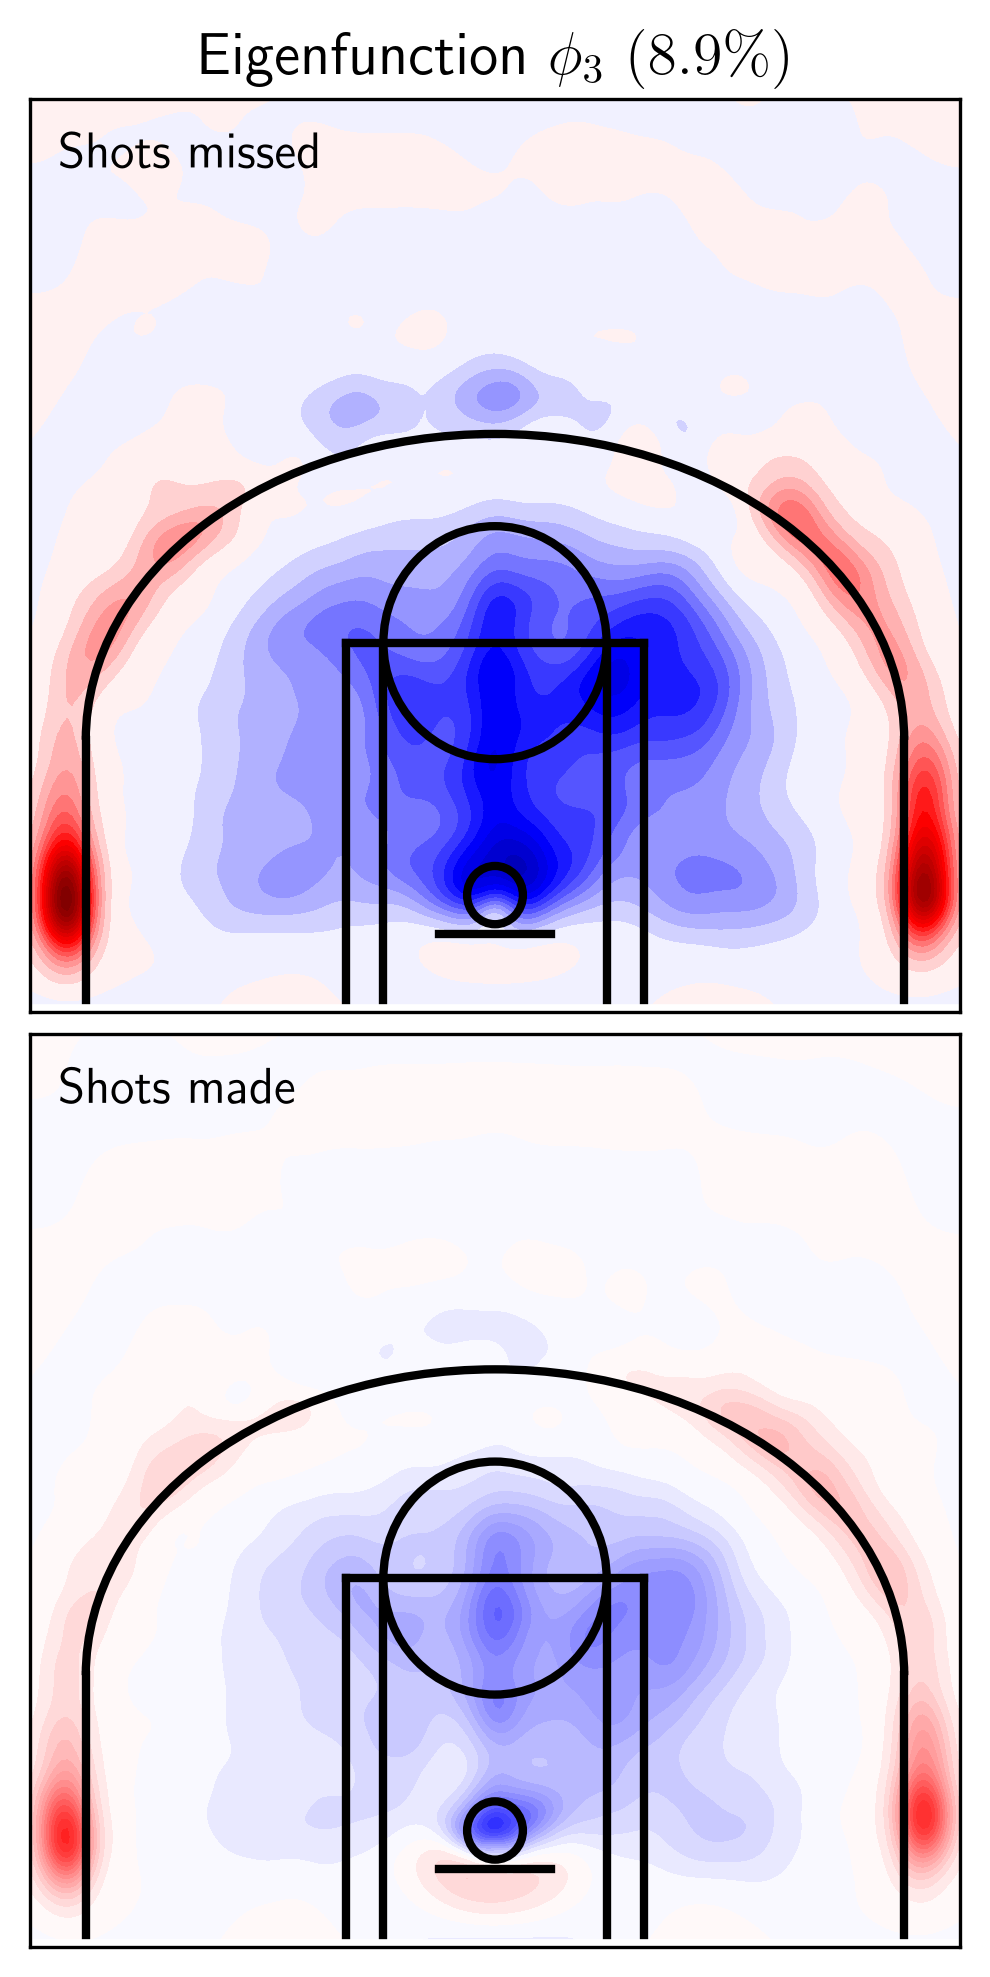

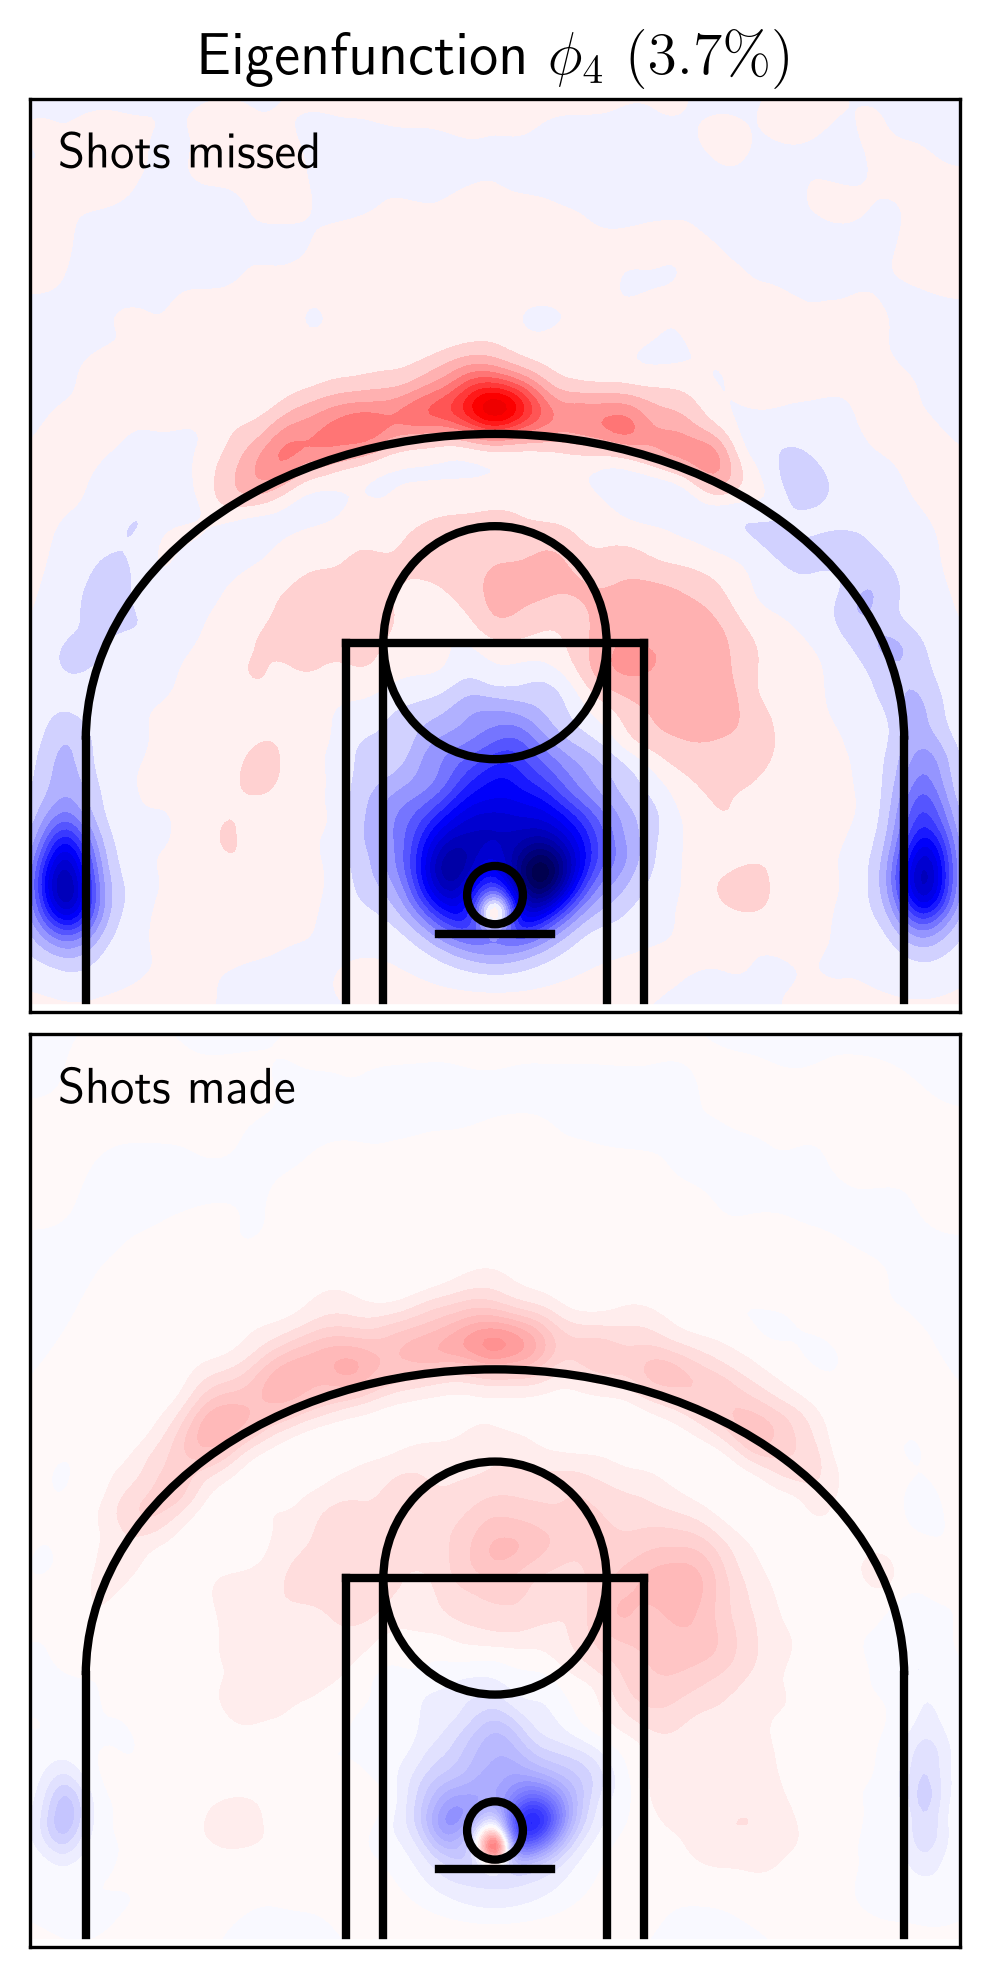

In [8]:
# Eigenfunctions
for idx in range(4):
    fig, ax = plt.subplots(
        2, 1,
        figsize=(4, 8),
        facecolor='white',
        edgecolor='black',
        dpi=300
    )
    ax[0], ax[1] = ShotCharts.components_chart_2(
        ax[0], ax[1], mfpca, idx, 'Shots missed', 'Shots made'
    )
    ax[0].set_title(f"Eigenfunction $\\phi_{{{idx + 1}}}~({pct[idx]:.1f}\\%)$", fontsize='x-large')

    plt.subplots_adjust(hspace=0.025)
    plt.savefig(f'./figures/eigenfunction_{idx + 1}_normalized_cv.eps', transparent=True, format='eps')
    plt.show()

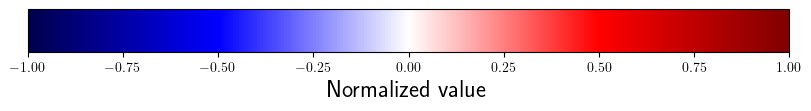

In [6]:
class MidpointNormalize(mpl.colors.Normalize):
    def __init__(self, vmin=None, vmax=None, vcenter=None, clip=False):
        self.vcenter = vcenter
        super().__init__(vmin, vmax, clip)

    def __call__(self, value, clip=None):
        # I'm ignoring masked values and all kinds of edge cases to make a
        # simple example...
        # Note also that we must extrapolate beyond vmin/vmax
        x, y = [self.vmin, self.vcenter, self.vmax], [0, 0.5, 1.]
        return np.ma.masked_array(
            np.interp(value, x, y, left=-np.inf, right=np.inf)
        )

    def inverse(self, value):
        y, x = [self.vmin, self.vcenter, self.vmax], [0, 0.5, 1]
        return np.interp(value, x, y, left=-np.inf, right=np.inf)

fig, ax = plt.subplots(figsize=(8, 1), layout='constrained')

cmap = mpl.cm.seismic
norm = MidpointNormalize(vmin=-1, vcenter=0, vmax=1)

cb = fig.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=ax, orientation='horizontal'
)
cb.set_label(label='Normalized value', fontsize='xx-large')

plt.savefig('./figures/colorbar2.eps', transparent=True, format='eps')
plt.show()